In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/energy_features.csv")

In [ ]:
df["time"] = pd.to_datetime(df["time"], utc=True)

In [ ]:
df["time"] = pd.to_datetime(df["time"], utc=True)

In [ ]:
print(df.shape)

(34859, 20)


In [ ]:
print(df[["time", "load", "price", "y_load_tplus1"]].head())

                       time     load  price  y_load_tplus1
0 2015-01-08 05:00:00+00:00  22551.0  44.81        22543.0
1 2015-01-08 06:00:00+00:00  22543.0  44.81        24042.0
2 2015-01-08 07:00:00+00:00  24042.0  46.85        25932.0
3 2015-01-08 08:00:00+00:00  25932.0  49.00        27664.0
4 2015-01-08 09:00:00+00:00  27664.0  54.36        28448.0


In [ ]:
opt_df = df[["time", "price", "y_load_tplus1"]].copy()

In [ ]:
opt_df = df[["time", "price", "y_load_tplus1"]].copy()

In [ ]:
print(opt_df.head())

                       time  price  y_load_tplus1
0 2015-01-08 05:00:00+00:00  44.81        22543.0
1 2015-01-08 06:00:00+00:00  44.81        24042.0
2 2015-01-08 07:00:00+00:00  46.85        25932.0
3 2015-01-08 08:00:00+00:00  49.00        27664.0
4 2015-01-08 09:00:00+00:00  54.36        28448.0


In [ ]:
opt_df = opt_df.rename(columns={"y_load_tplus1": "forecast_load"})

In [ ]:
print(opt_df.head())

                       time  price  forecast_load
0 2015-01-08 05:00:00+00:00  44.81        22543.0
1 2015-01-08 06:00:00+00:00  44.81        24042.0
2 2015-01-08 07:00:00+00:00  46.85        25932.0
3 2015-01-08 08:00:00+00:00  49.00        27664.0
4 2015-01-08 09:00:00+00:00  54.36        28448.0


In [ ]:
battery_capacity = 500

In [ ]:
max_charge_power = 100

In [ ]:
max_discharge_power = 100

In [ ]:
charge_efficiency = 0.95

In [ ]:
discharge_efficiency = 0.95

In [ ]:
initial_soc = 250

In [ ]:
time_horizon = 24

In [ ]:
print("Battery capacity:", battery_capacity)
print("Max charge power:", max_charge_power)
print("Max discharge power:", max_discharge_power)
print("Charge efficiency:", charge_efficiency)
print("Discharge efficiency:", discharge_efficiency)
print("Initial SOC:", initial_soc)
print("Time horizon:", time_horizon)

Battery capacity: 500
Max charge power: 100
Max discharge power: 100
Charge efficiency: 0.95
Discharge efficiency: 0.95
Initial SOC: 250
Time horizon: 24


**select one 24-hour test window and calculate the baseline electricity cost before battery optimization**

In [ ]:
sample_day = opt_df.iloc[:24].copy()

In [ ]:
print(sample_day)

                        time  price  forecast_load
0  2015-01-08 05:00:00+00:00  44.81        22543.0
1  2015-01-08 06:00:00+00:00  44.81        24042.0
2  2015-01-08 07:00:00+00:00  46.85        25932.0
3  2015-01-08 08:00:00+00:00  49.00        27664.0
4  2015-01-08 09:00:00+00:00  54.36        28448.0
5  2015-01-08 10:00:00+00:00  61.98        28881.0
6  2015-01-08 11:00:00+00:00  62.47        29329.0
7  2015-01-08 12:00:00+00:00  62.93        29026.0
8  2015-01-08 13:00:00+00:00  61.98        28237.0
9  2015-01-08 14:00:00+00:00  57.48        27868.0
10 2015-01-08 15:00:00+00:00  54.38        27654.0
11 2015-01-08 16:00:00+00:00  54.36        27507.0
12 2015-01-08 17:00:00+00:00  52.04        27544.0
13 2015-01-08 18:00:00+00:00  54.38        27578.0
14 2015-01-08 19:00:00+00:00  60.33        28222.0
15 2015-01-08 20:00:00+00:00  66.00        28221.0
16 2015-01-08 21:00:00+00:00  63.60        26436.0
17 2015-01-08 22:00:00+00:00  55.50        27485.0
18 2015-01-08 23:00:00+00:00  6

In [ ]:
sample_day["baseline_cost"] = sample_day["forecast_load"] * sample_day["price"]

In [ ]:
baseline_total_cost = sample_day["baseline_cost"].sum()

In [ ]:
print(sample_day[["time", "price", "forecast_load", "baseline_cost"]])

                        time  price  forecast_load  baseline_cost
0  2015-01-08 05:00:00+00:00  44.81        22543.0     1010151.83
1  2015-01-08 06:00:00+00:00  44.81        24042.0     1077322.02
2  2015-01-08 07:00:00+00:00  46.85        25932.0     1214914.20
3  2015-01-08 08:00:00+00:00  49.00        27664.0     1355536.00
4  2015-01-08 09:00:00+00:00  54.36        28448.0     1546433.28
5  2015-01-08 10:00:00+00:00  61.98        28881.0     1790044.38
6  2015-01-08 11:00:00+00:00  62.47        29329.0     1832182.63
7  2015-01-08 12:00:00+00:00  62.93        29026.0     1826606.18
8  2015-01-08 13:00:00+00:00  61.98        28237.0     1750129.26
9  2015-01-08 14:00:00+00:00  57.48        27868.0     1601852.64
10 2015-01-08 15:00:00+00:00  54.38        27654.0     1503824.52
11 2015-01-08 16:00:00+00:00  54.36        27507.0     1495280.52
12 2015-01-08 17:00:00+00:00  52.04        27544.0     1433389.76
13 2015-01-08 18:00:00+00:00  54.38        27578.0     1499691.64
14 2015-01

In [ ]:
print("Baseline total cost:", baseline_total_cost)

Baseline total cost: 35179139.879999995


In [ ]:
low_price_threshold = sample_day["price"].quantile(0.25)

In [ ]:
high_price_threshold = sample_day["price"].quantile(0.75)

In [ ]:
print("Low price threshold:", low_price_threshold)
print("High price threshold:", high_price_threshold)

Low price threshold: 48.387499999999996
High price threshold: 60.8475


In [ ]:
sample_day["charge_kwh"] = 0.0
sample_day["discharge_kwh"] = 0.0
sample_day["soc"] = 0.0

In [ ]:
soc = initial_soc

In [ ]:
for i in range(len(sample_day)):
    price = sample_day.loc[i, "price"]

    if price <= low_price_threshold:
        charge = min(max_charge_power, battery_capacity - soc)
        discharge = 0
        soc += charge * charge_efficiency

    elif price >= high_price_threshold:
        discharge = min(max_discharge_power, soc)
        discharge = max(discharge, 0)   # 🔴 fix: no negative discharge
        charge = 0
        soc -= discharge / discharge_efficiency

    else:
        charge = 0
        discharge = 0

    soc = max(0, min(soc, battery_capacity))   # 🔴 fix: keep SOC within limits

    sample_day.loc[i, "charge_kwh"] = charge
    sample_day.loc[i, "discharge_kwh"] = discharge
    sample_day.loc[i, "soc"] = soc

In [ ]:
print(sample_day[["time", "price", "forecast_load", "charge_kwh", "discharge_kwh", "soc"]])

                        time  price  forecast_load  charge_kwh  discharge_kwh  \
0  2015-01-08 05:00:00+00:00  44.81        22543.0       100.0       0.000000   
1  2015-01-08 06:00:00+00:00  44.81        24042.0       100.0       0.000000   
2  2015-01-08 07:00:00+00:00  46.85        25932.0        60.0       0.000000   
3  2015-01-08 08:00:00+00:00  49.00        27664.0         0.0       0.000000   
4  2015-01-08 09:00:00+00:00  54.36        28448.0         0.0       0.000000   
5  2015-01-08 10:00:00+00:00  61.98        28881.0         0.0     100.000000   
6  2015-01-08 11:00:00+00:00  62.47        29329.0         0.0     100.000000   
7  2015-01-08 12:00:00+00:00  62.93        29026.0         0.0     100.000000   
8  2015-01-08 13:00:00+00:00  61.98        28237.0         0.0     100.000000   
9  2015-01-08 14:00:00+00:00  57.48        27868.0         0.0       0.000000   
10 2015-01-08 15:00:00+00:00  54.38        27654.0         0.0       0.000000   
11 2015-01-08 16:00:00+00:00

In [ ]:
sample_day["net_load"] = sample_day["forecast_load"] + sample_day["charge_kwh"] - sample_day["discharge_kwh"]

In [ ]:
sample_day["optimized_cost"] = sample_day["net_load"] * sample_day["price"]

In [ ]:
optimized_total_cost = sample_day["optimized_cost"].sum()

In [ ]:
savings = baseline_total_cost - optimized_total_cost

In [ ]:
savings_percent = (savings / baseline_total_cost) * 100

In [ ]:
print("Optimized total cost:", optimized_total_cost)
print("Total savings:", savings)
print("Savings percentage:", savings_percent)

Optimized total cost: 35174896.35368421
Total savings: 4243.5263157859445
Savings percentage: 0.012062621002847398


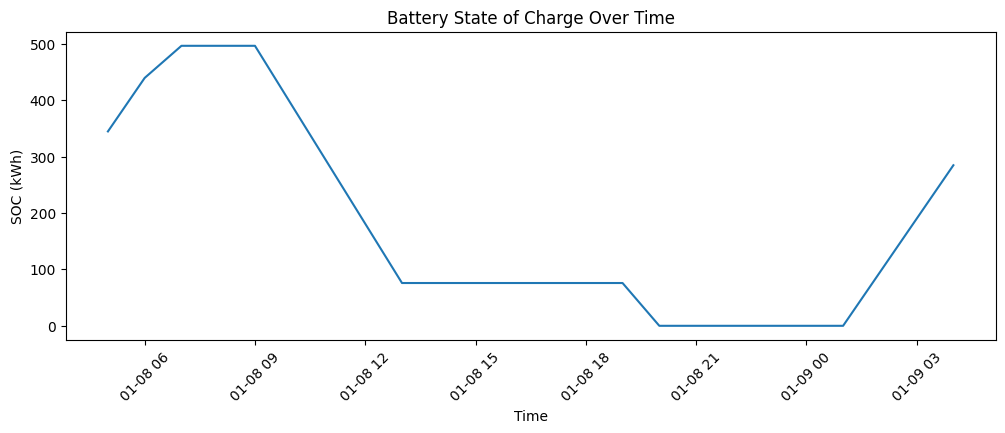

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(sample_day["time"], sample_day["soc"])
plt.title("Battery State of Charge Over Time")
plt.xlabel("Time")
plt.ylabel("SOC (kWh)")
plt.xticks(rotation=45)
plt.show()

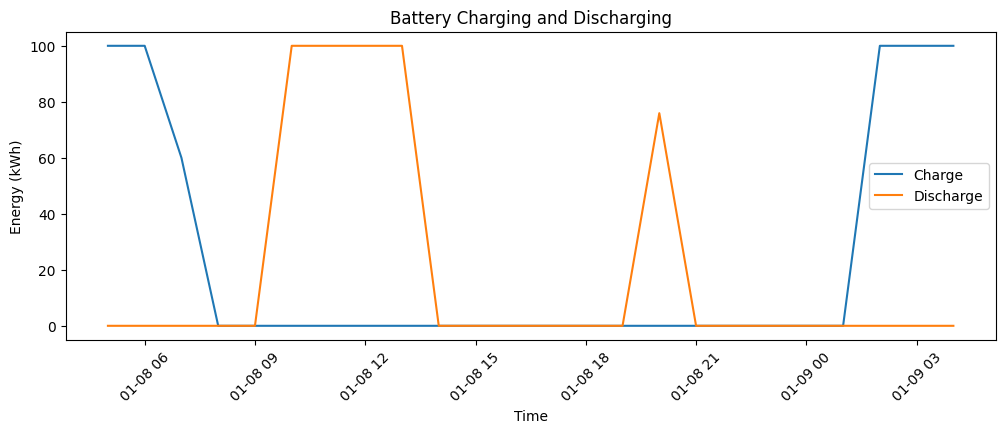

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(sample_day["time"], sample_day["charge_kwh"], label="Charge")
plt.plot(sample_day["time"], sample_day["discharge_kwh"], label="Discharge")
plt.title("Battery Charging and Discharging")
plt.xlabel("Time")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

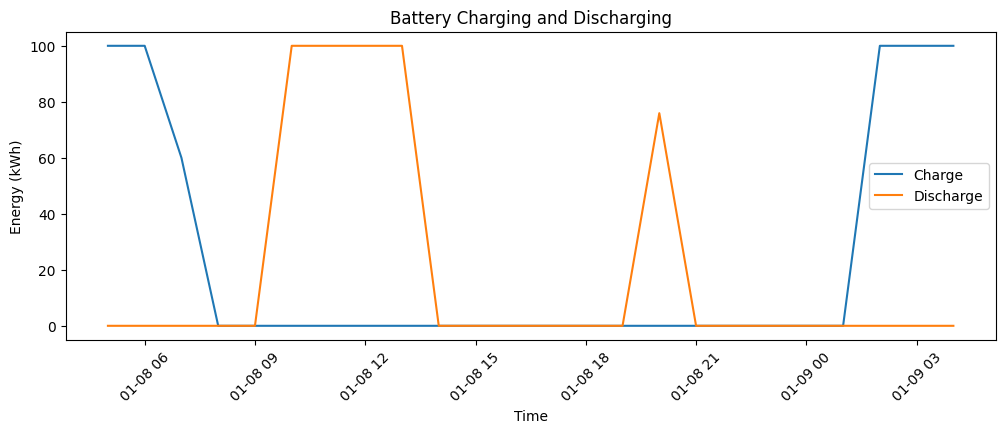

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(sample_day["time"], sample_day["charge_kwh"], label="Charge")
plt.plot(sample_day["time"], sample_day["discharge_kwh"], label="Discharge")
plt.title("Battery Charging and Discharging")
plt.xlabel("Time")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [ ]:
!pip install pulp

In [ ]:
from pulp import LpMinimize, LpProblem, LpVariable, lpSum

In [ ]:
model = LpProblem("Battery_Scheduling", LpMinimize)

In [ ]:
charge = LpVariable.dicts("charge", range(24), lowBound=0, upBound=max_charge_power)
discharge = LpVariable.dicts("discharge", range(24), lowBound=0, upBound=max_discharge_power)
soc = LpVariable.dicts("soc", range(24), lowBound=0, upBound=battery_capacity)

In [ ]:
model += lpSum([
    (sample_day.loc[t, "forecast_load"] + charge[t] - discharge[t]) * sample_day.loc[t, "price"]
    for t in range(24)
])

In [ ]:
model += soc[0] == initial_soc

In [ ]:
for t in range(1, 24):
    model += soc[t] == soc[t-1] + charge[t]*charge_efficiency - discharge[t]/discharge_efficiency

In [ ]:
model.solve()

1

In [ ]:
sample_day["opt_charge"] = [charge[t].varValue for t in range(24)]
sample_day["opt_discharge"] = [discharge[t].varValue for t in range(24)]
sample_day["opt_soc"] = [soc[t].varValue for t in range(24)]

In [ ]:
sample_day["opt_net_load"] = sample_day["forecast_load"] + sample_day["opt_charge"] - sample_day["opt_discharge"]
sample_day["opt_cost_lp"] = sample_day["opt_net_load"] * sample_day["price"]

optimized_cost_lp = sample_day["opt_cost_lp"].sum()

print("Optimized cost (LP):", optimized_cost_lp)

Optimized cost (LP): 35156290.442322135


In [ ]:
lp_savings = baseline_total_cost - optimized_cost_lp
lp_savings_percent = (lp_savings / baseline_total_cost) * 100

print("LP total savings:", lp_savings)
print("LP savings percentage:", lp_savings_percent)

LP total savings: 22849.43767786026
LP savings percentage: 0.06495166668600273


In [ ]:
print(sample_day[["time", "price", "forecast_load", "opt_charge", "opt_discharge", "opt_soc"]])

                        time  price  forecast_load  opt_charge  opt_discharge  \
0  2015-01-08 05:00:00+00:00  44.81        22543.0    0.000000          100.0   
1  2015-01-08 06:00:00+00:00  44.81        24042.0  100.000000            0.0   
2  2015-01-08 07:00:00+00:00  46.85        25932.0  100.000000            0.0   
3  2015-01-08 08:00:00+00:00  49.00        27664.0   63.157895            0.0   
4  2015-01-08 09:00:00+00:00  54.36        28448.0    0.000000            0.0   
5  2015-01-08 10:00:00+00:00  61.98        28881.0    0.000000          100.0   
6  2015-01-08 11:00:00+00:00  62.47        29329.0    0.000000          100.0   
7  2015-01-08 12:00:00+00:00  62.93        29026.0    0.000000          100.0   
8  2015-01-08 13:00:00+00:00  61.98        28237.0    0.000000          100.0   
9  2015-01-08 14:00:00+00:00  57.48        27868.0    0.000000            0.0   
10 2015-01-08 15:00:00+00:00  54.38        27654.0  100.000000            0.0   
11 2015-01-08 16:00:00+00:00

In [ ]:
import matplotlib.pyplot as plt

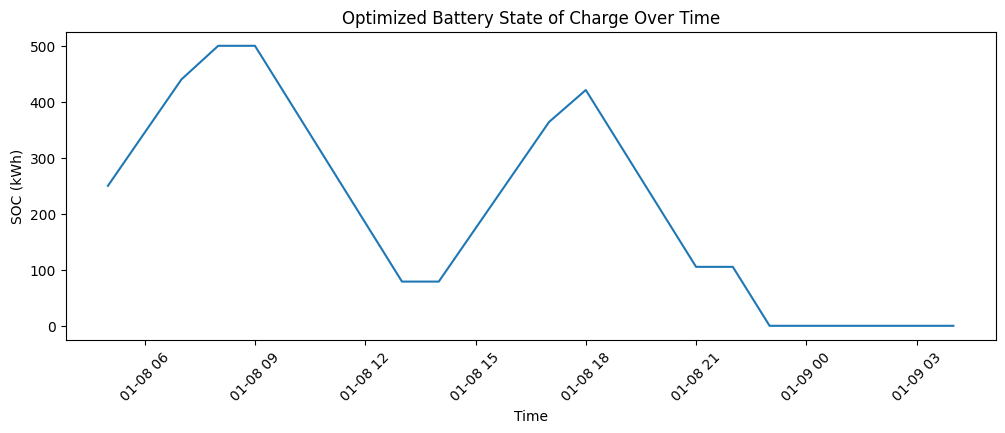

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(sample_day["time"], sample_day["opt_soc"])
plt.title("Optimized Battery State of Charge Over Time")
plt.xlabel("Time")
plt.ylabel("SOC (kWh)")
plt.xticks(rotation=45)
plt.show()

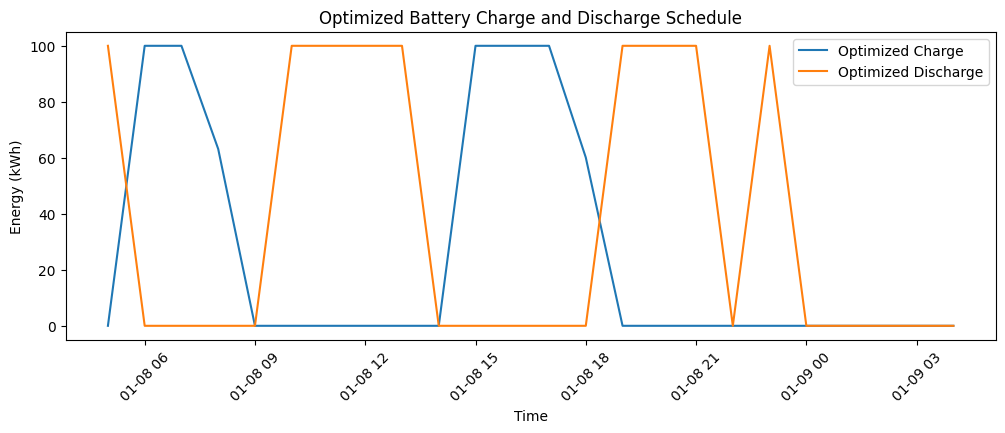

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(sample_day["time"], sample_day["opt_charge"], label="Optimized Charge")
plt.plot(sample_day["time"], sample_day["opt_discharge"], label="Optimized Discharge")
plt.title("Optimized Battery Charge and Discharge Schedule")
plt.xlabel("Time")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

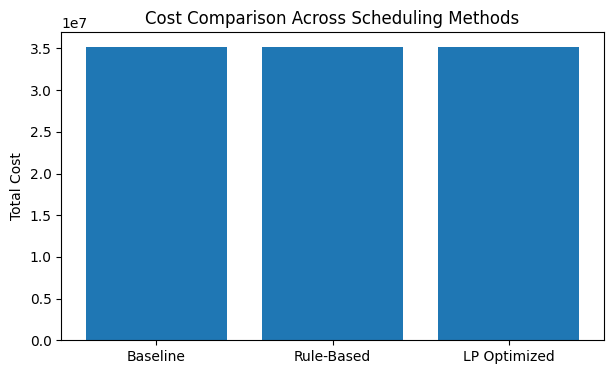

In [ ]:
cost_labels = ["Baseline", "Rule-Based", "LP Optimized"]
cost_values = [baseline_total_cost, optimized_total_cost, optimized_cost_lp]

plt.figure(figsize=(7, 4))
plt.bar(cost_labels, cost_values)
plt.title("Cost Comparison Across Scheduling Methods")
plt.ylabel("Total Cost")
plt.show()

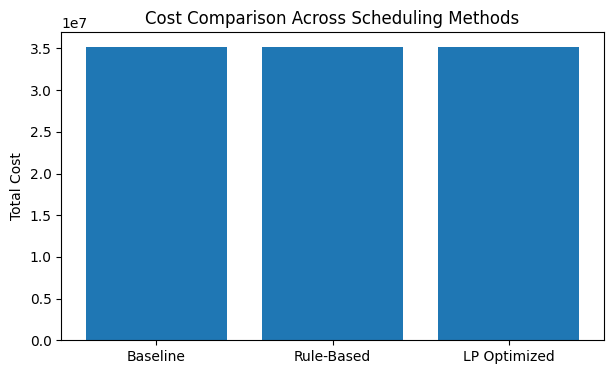

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(cost_labels, cost_values)
plt.title("Cost Comparison Across Scheduling Methods")
plt.ylabel("Total Cost")
plt.savefig("optimization_cost_comparison.png", bbox_inches="tight")
plt.show()

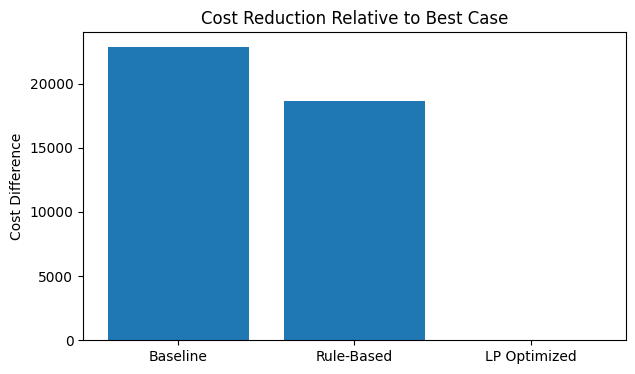

In [ ]:
adjusted_costs = [
    baseline_total_cost - min(cost_values),
    optimized_total_cost - min(cost_values),
    optimized_cost_lp - min(cost_values)
]

plt.figure(figsize=(7, 4))
plt.bar(cost_labels, adjusted_costs)
plt.title("Cost Reduction Relative to Best Case")
plt.ylabel("Cost Difference")
plt.show()

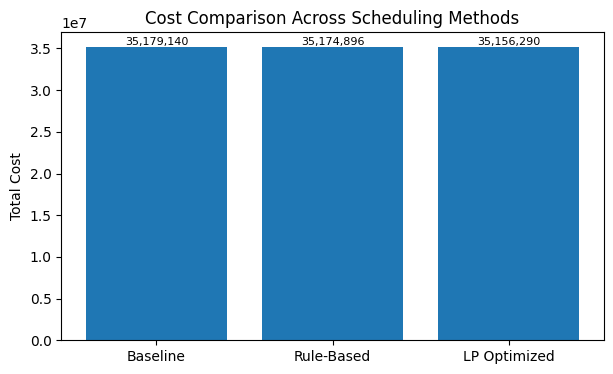

In [ ]:
plt.figure(figsize=(7, 4))
bars = plt.bar(cost_labels, cost_values)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:,.0f}',
             ha='center', va='bottom', fontsize=8)

plt.title("Cost Comparison Across Scheduling Methods")
plt.ylabel("Total Cost")
plt.show()

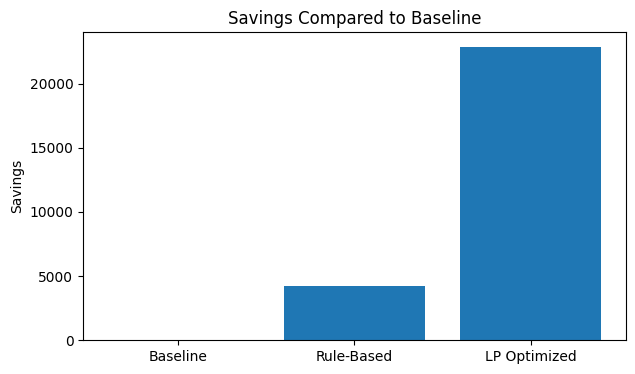

In [ ]:
savings_values = [
    0,
    baseline_total_cost - optimized_total_cost,
    baseline_total_cost - optimized_cost_lp
]

plt.figure(figsize=(7, 4))
plt.bar(cost_labels, savings_values)
plt.title("Savings Compared to Baseline")
plt.ylabel("Savings")
plt.show()

**Use ML Predictions in Optimization**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving predictions_histgb.csv to predictions_histgb.csv


In [ ]:
price_df = df[["time", "price"]].copy()

In [ ]:
pred_df = pd.read_csv('predictions_histgb.csv')
pred_df['time'] = pd.to_datetime(pred_df['time'], utc=True)
opt_pred_df = pd.merge(pred_df, price_df, on="time", how="inner")

In [ ]:
print(opt_pred_df.head())

                       time  predicted_load  price
0 2018-03-16 08:00:00+00:00    35037.593751  55.99
1 2018-03-16 09:00:00+00:00    35003.075740  52.80
2 2018-03-16 10:00:00+00:00    34670.488643  51.17
3 2018-03-16 11:00:00+00:00    34145.824847  50.54
4 2018-03-16 12:00:00+00:00    33230.179661  50.18


In [ ]:
sample_day_pred = opt_pred_df.iloc[:24].copy()

In [ ]:
sample_day_pred = sample_day_pred.rename(columns={"predicted_load": "forecast_load"})

In [ ]:
sample_day = sample_day_pred.copy()

In [ ]:
from pulp import LpMinimize, LpProblem, LpVariable, lpSum

# Re-define and solve the LP model using the updated 'sample_day'
model_pred = LpProblem("Battery_Scheduling_ML_Forecast", LpMinimize)

charge_pred = LpVariable.dicts("charge", range(time_horizon), lowBound=0, upBound=max_charge_power)
discharge_pred = LpVariable.dicts("discharge", range(time_horizon), lowBound=0, upBound=max_discharge_power)
soc_pred = LpVariable.dicts("soc", range(time_horizon), lowBound=0, upBound=battery_capacity)

# Objective function: Minimize total electricity cost
model_pred += lpSum([
    (sample_day.loc[t, "forecast_load"] + charge_pred[t] - discharge_pred[t]) * sample_day.loc[t, "price"]
    for t in range(time_horizon)
])

# Constraints
model_pred += soc_pred[0] == initial_soc

for t in range(1, time_horizon):
    model_pred += soc_pred[t] == soc_pred[t-1] + charge_pred[t]*charge_efficiency - discharge_pred[t]/discharge_efficiency

# Solve the model
model_pred.solve()

# Store optimized results in sample_day
sample_day["opt_charge"] = [charge_pred[t].varValue for t in range(time_horizon)]
sample_day["opt_discharge"] = [discharge_pred[t].varValue for t in range(time_horizon)]
sample_day["opt_soc"] = [soc_pred[t].varValue for t in range(time_horizon)]

# Calculate net load and optimized cost using ML forecast
sample_day["opt_net_load"] = sample_day["forecast_load"] + sample_day["opt_charge"] - sample_day["opt_discharge"]
sample_day["opt_cost_pred"] = sample_day["opt_net_load"] * sample_day["price"]

optimized_cost_pred = sample_day["opt_cost_pred"].sum()

print("Optimized cost using ML forecast:", optimized_cost_pred)

Optimized cost using ML forecast: 32378382.798881598


In [ ]:
print(sample_day_pred["time"].min(), sample_day_pred["time"].max())

2018-03-16 08:00:00+00:00 2018-03-17 07:00:00+00:00


In [ ]:
sample_day = df[df["time"].isin(sample_day_pred["time"])].copy()

In [ ]:
sample_day = sample_day[["time", "price", "y_load_tplus1"]].copy()
sample_day = sample_day.rename(columns={"y_load_tplus1": "forecast_load"})

In [ ]:
# Create the actual-load comparison window using the exact same 24-hour timestamps
sample_day_actual = df[df["time"].isin(sample_day_pred["time"])].copy()

# Keep only needed columns
sample_day_actual = sample_day_actual[["time", "price", "y_load_tplus1"]].copy()

# Rename for consistency
sample_day_actual = sample_day_actual.rename(columns={"y_load_tplus1": "forecast_load"})

# Sort and reset index
sample_day_actual = sample_day_actual.sort_values("time").reset_index(drop=True)

print(sample_day_actual.head())
print(sample_day_actual["time"].min(), sample_day_actual["time"].max())
print(sample_day_actual.shape)

                       time  price  forecast_load
0 2018-03-16 08:00:00+00:00  55.99        34920.0
1 2018-03-16 09:00:00+00:00  52.80        34837.0
2 2018-03-16 10:00:00+00:00  51.17        34651.0
3 2018-03-16 11:00:00+00:00  50.54        34338.0
4 2018-03-16 12:00:00+00:00  50.18        33245.0
2018-03-16 08:00:00+00:00 2018-03-17 07:00:00+00:00
(24, 3)


In [ ]:
sample_day_actual["baseline_cost"] = sample_day_actual["forecast_load"] * sample_day_actual["price"]

baseline_total_cost_aligned = sample_day_actual["baseline_cost"].sum()

print("Aligned baseline total cost:", baseline_total_cost_aligned)

Aligned baseline total cost: 32368364.68


In [ ]:
# Battery settings
battery_capacity = 500
max_charge_power = 100
max_discharge_power = 100
charge_efficiency = 0.95
discharge_efficiency = 0.95
initial_soc = 250

# Copy window
rule_day = sample_day_actual.copy()

# Price thresholds
low_price_threshold = rule_day["price"].quantile(0.25)
high_price_threshold = rule_day["price"].quantile(0.75)

print("Low price threshold:", low_price_threshold)
print("High price threshold:", high_price_threshold)

# Create columns
rule_day["charge_kwh"] = 0.0
rule_day["discharge_kwh"] = 0.0
rule_day["soc"] = 0.0

soc = initial_soc

for i in range(len(rule_day)):
    price = rule_day.loc[i, "price"]

    if price <= low_price_threshold:
        charge = min(max_charge_power, battery_capacity - soc)
        charge = max(charge, 0)
        discharge = 0
        soc += charge * charge_efficiency

    elif price >= high_price_threshold:
        discharge = min(max_discharge_power, soc)
        discharge = max(discharge, 0)
        charge = 0
        soc -= discharge / discharge_efficiency

    else:
        charge = 0
        discharge = 0

    soc = max(0, min(soc, battery_capacity))

    rule_day.loc[i, "charge_kwh"] = charge
    rule_day.loc[i, "discharge_kwh"] = discharge
    rule_day.loc[i, "soc"] = soc

# Rule-based cost
rule_day["net_load"] = rule_day["forecast_load"] + rule_day["charge_kwh"] - rule_day["discharge_kwh"]
rule_day["optimized_cost"] = rule_day["net_load"] * rule_day["price"]

optimized_total_cost_rule_aligned = rule_day["optimized_cost"].sum()
rule_savings_aligned = baseline_total_cost_aligned - optimized_total_cost_rule_aligned
rule_savings_percent_aligned = (rule_savings_aligned / baseline_total_cost_aligned) * 100

print("Aligned rule-based total cost:", optimized_total_cost_rule_aligned)
print("Aligned rule-based savings:", rule_savings_aligned)
print("Aligned rule-based savings %:", rule_savings_percent_aligned)

Low price threshold: 37.885
High price threshold: 50.1725
Aligned rule-based total cost: 32374427.561578944
Aligned rule-based savings: -6062.8815789446235
Aligned rule-based savings %: -0.018730886280117823


In [ ]:
!pip install pulp

In [ ]:
from pulp import LpMinimize, LpProblem, LpVariable, lpSum

In [ ]:
# Copy aligned actual window
lp_actual_day = sample_day_actual.copy()

# Build LP model
model_actual = LpProblem("Battery_Scheduling_Actual", LpMinimize)

charge_actual = LpVariable.dicts("charge_actual", range(24), lowBound=0, upBound=max_charge_power)
discharge_actual = LpVariable.dicts("discharge_actual", range(24), lowBound=0, upBound=max_discharge_power)
soc_actual = LpVariable.dicts("soc_actual", range(24), lowBound=0, upBound=battery_capacity)

# Objective
model_actual += lpSum([
    (lp_actual_day.loc[t, "forecast_load"] + charge_actual[t] - discharge_actual[t]) * lp_actual_day.loc[t, "price"]
    for t in range(24)
])

# Initial SOC
model_actual += soc_actual[0] == initial_soc

# SOC update
for t in range(1, 24):
    model_actual += soc_actual[t] == soc_actual[t-1] + charge_actual[t] * charge_efficiency - discharge_actual[t] / discharge_efficiency

# Solve
model_actual.solve()

# Extract results
lp_actual_day["opt_charge"] = [charge_actual[t].varValue for t in range(24)]
lp_actual_day["opt_discharge"] = [discharge_actual[t].varValue for t in range(24)]
lp_actual_day["opt_soc"] = [soc_actual[t].varValue for t in range(24)]

# Cost
lp_actual_day["opt_net_load"] = lp_actual_day["forecast_load"] + lp_actual_day["opt_charge"] - lp_actual_day["opt_discharge"]
lp_actual_day["opt_cost_lp"] = lp_actual_day["opt_net_load"] * lp_actual_day["price"]

optimized_cost_lp_actual_aligned = lp_actual_day["opt_cost_lp"].sum()
lp_actual_savings_aligned = baseline_total_cost_aligned - optimized_cost_lp_actual_aligned
lp_actual_savings_percent_aligned = (lp_actual_savings_aligned / baseline_total_cost_aligned) * 100

print("Aligned LP cost using actual future load:", optimized_cost_lp_actual_aligned)
print("Aligned LP savings using actual future load:", lp_actual_savings_aligned)
print("Aligned LP savings % using actual future load:", lp_actual_savings_percent_aligned)

Aligned LP cost using actual future load: 32349569.790668197
Aligned LP savings using actual future load: 18794.889331802726
Aligned LP savings % using actual future load: 0.058065612883482644


In [ ]:
# Prepare ML prediction window
sample_day_pred = sample_day_pred.sort_values("time").reset_index(drop=True)
sample_day_pred = sample_day_pred.rename(columns={"predicted_load": "forecast_load"})

print(sample_day_pred.head())
print(sample_day_pred["time"].min(), sample_day_pred["time"].max())
print(sample_day_pred.shape)

                       time  forecast_load  price
0 2018-03-16 08:00:00+00:00   35037.593751  55.99
1 2018-03-16 09:00:00+00:00   35003.075740  52.80
2 2018-03-16 10:00:00+00:00   34670.488643  51.17
3 2018-03-16 11:00:00+00:00   34145.824847  50.54
4 2018-03-16 12:00:00+00:00   33230.179661  50.18
2018-03-16 08:00:00+00:00 2018-03-17 07:00:00+00:00
(24, 3)


In [ ]:
# Build LP model using ML forecast
model_pred = LpProblem("Battery_Scheduling_Predicted", LpMinimize)

charge_pred = LpVariable.dicts("charge_pred", range(24), lowBound=0, upBound=max_charge_power)
discharge_pred = LpVariable.dicts("discharge_pred", range(24), lowBound=0, upBound=max_discharge_power)
soc_pred = LpVariable.dicts("soc_pred", range(24), lowBound=0, upBound=battery_capacity)

# Objective
model_pred += lpSum([
    (sample_day_pred.loc[t, "forecast_load"] + charge_pred[t] - discharge_pred[t]) * sample_day_pred.loc[t, "price"]
    for t in range(24)
])

# Initial SOC
model_pred += soc_pred[0] == initial_soc

# SOC update
for t in range(1, 24):
    model_pred += soc_pred[t] == soc_pred[t-1] + charge_pred[t] * charge_efficiency - discharge_pred[t] / discharge_efficiency

# Solve
model_pred.solve()

# Extract results
sample_day_pred["opt_charge"] = [charge_pred[t].varValue for t in range(24)]
sample_day_pred["opt_discharge"] = [discharge_pred[t].varValue for t in range(24)]
sample_day_pred["opt_soc"] = [soc_pred[t].varValue for t in range(24)]

# Cost
sample_day_pred["opt_net_load"] = sample_day_pred["forecast_load"] + sample_day_pred["opt_charge"] - sample_day_pred["opt_discharge"]
sample_day_pred["opt_cost_pred"] = sample_day_pred["opt_net_load"] * sample_day_pred["price"]

optimized_cost_lp_pred_aligned = sample_day_pred["opt_cost_pred"].sum()
lp_pred_savings_aligned = baseline_total_cost_aligned - optimized_cost_lp_pred_aligned
lp_pred_savings_percent_aligned = (lp_pred_savings_aligned / baseline_total_cost_aligned) * 100

print("Aligned LP cost using ML forecast:", optimized_cost_lp_pred_aligned)
print("Aligned LP savings using ML forecast:", lp_pred_savings_aligned)
print("Aligned LP savings % using ML forecast:", lp_pred_savings_percent_aligned)

Aligned LP cost using ML forecast: 32378382.798881598
Aligned LP savings using ML forecast: -10018.118881598115
Aligned LP savings % using ML forecast: -0.030950339878579602


In [ ]:
final_opt_results = pd.DataFrame({
    "Method": [
        "Baseline",
        "Rule-Based",
        "LP Actual Future Load",
        "LP ML Forecast"
    ],
    "Total_Cost": [
        baseline_total_cost_aligned,
        optimized_total_cost_rule_aligned,
        optimized_cost_lp_actual_aligned,
        optimized_cost_lp_pred_aligned
    ]
})

final_opt_results["Savings_vs_Baseline"] = baseline_total_cost_aligned - final_opt_results["Total_Cost"]
final_opt_results["Savings_Percent"] = (final_opt_results["Savings_vs_Baseline"] / baseline_total_cost_aligned) * 100

print(final_opt_results)

                  Method    Total_Cost  Savings_vs_Baseline  Savings_Percent
0               Baseline  3.236836e+07             0.000000         0.000000
1             Rule-Based  3.237443e+07         -6062.881579        -0.018731
2  LP Actual Future Load  3.234957e+07         18794.889332         0.058066
3         LP ML Forecast  3.237838e+07        -10018.118882        -0.030950


In [ ]:
from pulp import LpMinimize, LpProblem, LpVariable, lpSum, LpBinary

In [ ]:
# Improved LP model using ML forecast
model_pred_improved = LpProblem("Battery_Scheduling_Predicted_Improved", LpMinimize)

charge_pred = LpVariable.dicts("charge_pred", range(24), lowBound=0, upBound=max_charge_power)
discharge_pred = LpVariable.dicts("discharge_pred", range(24), lowBound=0, upBound=max_discharge_power)
soc_pred = LpVariable.dicts("soc_pred", range(24), lowBound=0, upBound=battery_capacity)
is_charging = LpVariable.dicts("is_charging", range(24), cat=LpBinary)

In [ ]:
model_pred_improved += lpSum([
    (sample_day_pred.loc[t, "forecast_load"] + charge_pred[t] - discharge_pred[t]) * sample_day_pred.loc[t, "price"]
    for t in range(24)
])

In [ ]:
model_pred_improved += soc_pred[0] == initial_soc

In [ ]:
for t in range(1, 24):
    model_pred_improved += soc_pred[t] == soc_pred[t-1] + charge_pred[t] * charge_efficiency - discharge_pred[t] / discharge_efficiency

In [ ]:
model_pred_improved += soc_pred[23] == initial_soc

In [ ]:
for t in range(24):
    model_pred_improved += charge_pred[t] <= max_charge_power * is_charging[t]
    model_pred_improved += discharge_pred[t] <= max_discharge_power * (1 - is_charging[t])

In [ ]:
for t in range(24):
    model_pred_improved += discharge_pred[t] <= sample_day_pred.loc[t, "forecast_load"]

In [ ]:
model_pred_improved.solve()

1

In [ ]:
sample_day_pred["opt_charge_improved"] = [charge_pred[t].varValue for t in range(24)]
sample_day_pred["opt_discharge_improved"] = [discharge_pred[t].varValue for t in range(24)]
sample_day_pred["opt_soc_improved"] = [soc_pred[t].varValue for t in range(24)]

In [ ]:
sample_day_pred["opt_net_load_improved"] = (
    sample_day_pred["forecast_load"]
    + sample_day_pred["opt_charge_improved"]
    - sample_day_pred["opt_discharge_improved"]
)

sample_day_pred["opt_cost_pred_improved"] = (
    sample_day_pred["opt_net_load_improved"] * sample_day_pred["price"]
)

optimized_cost_pred_improved = sample_day_pred["opt_cost_pred_improved"].sum()
improved_savings = baseline_total_cost_aligned - optimized_cost_pred_improved
improved_savings_percent = (improved_savings / baseline_total_cost_aligned) * 100

print("Improved optimized cost using ML forecast:", optimized_cost_pred_improved)
print("Improved savings using ML forecast:", improved_savings)
print("Improved savings % using ML forecast:", improved_savings_percent)

Improved optimized cost using ML forecast: 32387870.710248426
Improved savings using ML forecast: -19506.0302484259
Improved savings % using ML forecast: -0.06026263742782912


In [ ]:
# Start from ML prediction window
final_df = sample_day_pred.copy()

# Merge actual load
final_df = final_df.merge(
    sample_day_actual[["time", "forecast_load"]],
    on="time",
    how="left"
)

# Rename columns
final_df = final_df.rename(columns={
    "forecast_load_x": "predicted_load",
    "forecast_load_y": "actual_load"
})

# Baseline cost (actual load)
final_df["baseline_cost"] = final_df["actual_load"] * final_df["price"]

# Rule-based cost (merge from rule_day)
rule_day_small = rule_day[["time", "optimized_cost"]].rename(columns={"optimized_cost": "rule_cost"})
final_df = final_df.merge(rule_day_small, on="time", how="left")

# LP actual cost
lp_actual_small = lp_actual_day[["time", "opt_cost_lp"]].rename(columns={"opt_cost_lp": "lp_actual_cost"})
final_df = final_df.merge(lp_actual_small, on="time", how="left")

# LP ML cost (improved version if you want)
lp_pred_small = sample_day_pred[["time", "opt_cost_pred_improved"]].rename(columns={"opt_cost_pred_improved": "lp_pred_cost"})
final_df = final_df.merge(lp_pred_small, on="time", how="left")

# Check
print(final_df.head())

# Save CSV
final_df.to_csv("powerbi_dataset.csv", index=False)

print("Power BI dataset saved successfully")

                       time  predicted_load  price  opt_charge  opt_discharge  \
0 2018-03-16 08:00:00+00:00    35037.593751  55.99         0.0          100.0   
1 2018-03-16 09:00:00+00:00    35003.075740  52.80         0.0          100.0   
2 2018-03-16 10:00:00+00:00    34670.488643  51.17         0.0          100.0   
3 2018-03-16 11:00:00+00:00    34145.824847  50.54         0.0           37.5   
4 2018-03-16 12:00:00+00:00    33230.179661  50.18         0.0            0.0   

      opt_soc  opt_net_load  opt_cost_pred  opt_charge_improved  \
0  250.000000  34937.593751   1.956156e+06                  0.0   
1  144.736840  34903.075740   1.842882e+06                  0.0   
2   39.473684  34570.488643   1.768972e+06                  0.0   
3    0.000000  34108.324847   1.723835e+06                  0.0   
4    0.000000  33230.179661   1.667490e+06                  0.0   

   opt_discharge_improved  opt_soc_improved  opt_net_load_improved  \
0                   100.0        250.000

In [ ]:
print(final_df.isnull().sum())

time                      0
predicted_load            0
price                     0
opt_charge                0
opt_discharge             0
opt_soc                   0
opt_net_load              0
opt_cost_pred             0
opt_charge_improved       0
opt_discharge_improved    0
opt_soc_improved          0
opt_net_load_improved     0
opt_cost_pred_improved    0
actual_load               0
baseline_cost             0
rule_cost                 0
lp_actual_cost            0
lp_pred_cost              0
dtype: int64


In [ ]:
from google.colab import files
files.download("powerbi_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from pulp import LpMinimize, LpProblem, LpVariable, lpSum, LpBinary

In [ ]:
def run_battery_optimization(data, battery_capacity, max_charge_power, max_discharge_power,
                             charge_efficiency, discharge_efficiency, initial_soc):
    model = LpProblem("Battery_Scheduling_Scenario", LpMinimize)

    charge = LpVariable.dicts("charge", range(len(data)), lowBound=0, upBound=max_charge_power)
    discharge = LpVariable.dicts("discharge", range(len(data)), lowBound=0, upBound=max_discharge_power)
    soc = LpVariable.dicts("soc", range(len(data)), lowBound=0, upBound=battery_capacity)
    is_charging = LpVariable.dicts("is_charging", range(len(data)), cat=LpBinary)

    model += lpSum([
        (data.loc[t, "forecast_load"] + charge[t] - discharge[t]) * data.loc[t, "price"]
        for t in range(len(data))
    ])

    model += soc[0] == initial_soc

    for t in range(1, len(data)):
        model += soc[t] == soc[t-1] + charge[t] * charge_efficiency - discharge[t] / discharge_efficiency

    model += soc[len(data)-1] == initial_soc

    for t in range(len(data)):
        model += charge[t] <= max_charge_power * is_charging[t]
        model += discharge[t] <= max_discharge_power * (1 - is_charging[t])
        model += discharge[t] <= data.loc[t, "forecast_load"]

    model.solve()

    result = data.copy()
    result["opt_charge"] = [charge[t].varValue for t in range(len(data))]
    result["opt_discharge"] = [discharge[t].varValue for t in range(len(data))]
    result["opt_soc"] = [soc[t].varValue for t in range(len(data))]
    result["opt_net_load"] = result["forecast_load"] + result["opt_charge"] - result["opt_discharge"]
    result["opt_cost"] = result["opt_net_load"] * result["price"]

    total_cost = result["opt_cost"].sum()

    return result, total_cost

In [ ]:
scenario_500, cost_500 = run_battery_optimization(
    sample_day_pred.copy(),
    battery_capacity=500,
    max_charge_power=100,
    max_discharge_power=100,
    charge_efficiency=0.95,
    discharge_efficiency=0.95,
    initial_soc=250
)

In [ ]:
scenario_1000, cost_1000 = run_battery_optimization(
    sample_day_pred.copy(),
    battery_capacity=1000,
    max_charge_power=100,
    max_discharge_power=100,
    charge_efficiency=0.95,
    discharge_efficiency=0.95,
    initial_soc=500
)

In [ ]:
savings_500 = baseline_total_cost_aligned - cost_500
savings_1000 = baseline_total_cost_aligned - cost_1000

savings_pct_500 = (savings_500 / baseline_total_cost_aligned) * 100
savings_pct_1000 = (savings_1000 / baseline_total_cost_aligned) * 100

print("500 kWh cost:", cost_500)
print("500 kWh savings:", savings_500)
print("500 kWh savings %:", savings_pct_500)

print("1000 kWh cost:", cost_1000)
print("1000 kWh savings:", savings_1000)
print("1000 kWh savings %:", savings_pct_1000)

500 kWh cost: 32387870.710248426
500 kWh savings: -19506.0302484259
500 kWh savings %: -0.06026263742782912
1000 kWh cost: 32385664.799642827
1000 kWh savings: -17300.11964282766
1000 kWh savings %: -0.05344761718381523


In [ ]:
scenario_1000_power200, cost_1000_power200 = run_battery_optimization(
    sample_day_pred.copy(),
    battery_capacity=1000,
    max_charge_power=200,
    max_discharge_power=200,
    charge_efficiency=0.95,
    discharge_efficiency=0.95,
    initial_soc=500
)

In [ ]:
savings_1000_power200 = baseline_total_cost_aligned - cost_1000_power200

In [ ]:
savings_pct_1000_power200 = (savings_1000_power200 / baseline_total_cost_aligned) * 100

In [ ]:
print("1000 kWh, 200 kW cost:", cost_1000_power200)
print("1000 kWh, 200 kW savings:", savings_1000_power200)
print("1000 kWh, 200 kW savings %:", savings_pct_1000_power200)

1000 kWh, 200 kW cost: 32378563.732356198
1000 kWh, 200 kW savings: -10199.05235619843
1000 kWh, 200 kW savings %: -0.03150932231834466


In [ ]:
peak_price_threshold = sample_day_pred["price"].quantile(0.75)
print("Peak price threshold:", peak_price_threshold)

Peak price threshold: 50.1725


In [ ]:
from pulp import LpMinimize, LpProblem, LpVariable, lpSum, LpBinary

def run_battery_optimization_peak(data, battery_capacity, max_charge_power, max_discharge_power,
                                  charge_efficiency, discharge_efficiency, initial_soc,
                                  peak_price_threshold):
    model = LpProblem("Battery_Scheduling_Peak", LpMinimize)

    charge = LpVariable.dicts("charge", range(len(data)), lowBound=0, upBound=max_charge_power)
    discharge = LpVariable.dicts("discharge", range(len(data)), lowBound=0, upBound=max_discharge_power)
    soc = LpVariable.dicts("soc", range(len(data)), lowBound=0, upBound=battery_capacity)
    is_charging = LpVariable.dicts("is_charging", range(len(data)), cat=LpBinary)

    model += lpSum([
        (data.loc[t, "forecast_load"] + charge[t] - discharge[t]) * data.loc[t, "price"]
        for t in range(len(data))
    ])

    model += soc[0] == initial_soc

    for t in range(1, len(data)):
        model += soc[t] == soc[t-1] + charge[t] * charge_efficiency - discharge[t] / discharge_efficiency

    model += soc[len(data)-1] == initial_soc

    for t in range(len(data)):
        model += charge[t] <= max_charge_power * is_charging[t]
        model += discharge[t] <= max_discharge_power * (1 - is_charging[t])
        model += discharge[t] <= data.loc[t, "forecast_load"]

        if data.loc[t, "price"] < peak_price_threshold:
            model += discharge[t] == 0

    model.solve()

    result = data.copy()
    result["opt_charge"] = [charge[t].varValue for t in range(len(data))]
    result["opt_discharge"] = [discharge[t].varValue for t in range(len(data))]
    result["opt_soc"] = [soc[t].varValue for t in range(len(data))]
    result["opt_net_load"] = result["forecast_load"] + result["opt_charge"] - result["opt_discharge"]
    result["opt_cost"] = result["opt_net_load"] * result["price"]

    total_cost = result["opt_cost"].sum()

    return result, total_cost

In [ ]:
peak_price_threshold = sample_day_pred["price"].quantile(0.75)

scenario_peak, cost_peak = run_battery_optimization_peak(
    sample_day_pred.copy(),
    battery_capacity=1000,
    max_charge_power=200,
    max_discharge_power=200,
    charge_efficiency=0.95,
    discharge_efficiency=0.95,
    initial_soc=500,
    peak_price_threshold=peak_price_threshold
)

In [ ]:
savings_peak = baseline_total_cost_aligned - cost_peak
savings_pct_peak = (savings_peak / baseline_total_cost_aligned) * 100

print("Peak-price strategy cost:", cost_peak)
print("Peak-price strategy savings:", savings_peak)
print("Peak-price strategy savings %:", savings_pct_peak)

Peak-price strategy cost: 32379287.37104942
Peak-price strategy savings: -10922.691049419343
Peak-price strategy savings %: -0.033744957947067174


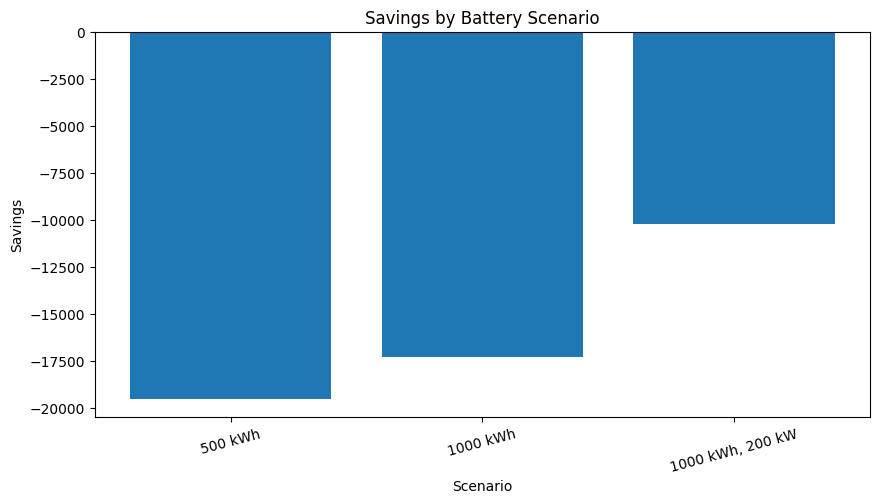

In [ ]:
import matplotlib.pyplot as plt

scenario_names = ["500 kWh", "1000 kWh", "1000 kWh, 200 kW"]
scenario_savings = [-19506.03, -17300.12, -10199.05]

plt.figure(figsize=(10, 5))
plt.bar(scenario_names, scenario_savings)
plt.title("Savings by Battery Scenario")
plt.xlabel("Scenario")
plt.ylabel("Savings")
plt.xticks(rotation=15)
plt.savefig("scenario_comparison.png", bbox_inches="tight")
plt.show()

In [ ]:
pred_df = pd.read_csv("predictions_histgb.csv")
pred_df["time"] = pd.to_datetime(pred_df["time"], utc=True)

price_df = pd.read_csv("energy_features.csv")
price_df["time"] = pd.to_datetime(price_df["time"], utc=True)

opt_pred_df = pd.merge(
    pred_df[["time", "predicted_load"]],
    price_df[["time", "price"]],
    on="time",
    how="inner"
)

opt_pred_df = opt_pred_df.rename(columns={"predicted_load": "forecast_load"})

sample_day_pred = opt_pred_df.iloc[:24].copy()

print(sample_day_pred.head())
print(sample_day_pred.shape)

                       time  forecast_load  price
0 2018-03-16 08:00:00+00:00   35037.593751  55.99
1 2018-03-16 09:00:00+00:00   35003.075740  52.80
2 2018-03-16 10:00:00+00:00   34670.488643  51.17
3 2018-03-16 11:00:00+00:00   34145.824847  50.54
4 2018-03-16 12:00:00+00:00   33230.179661  50.18
(24, 3)


In [ ]:
optimization_input_day = sample_day_pred[["time", "price", "forecast_load"]].copy()
optimization_input_day.to_csv("optimization_input_day.csv", index=False)
print(optimization_input_day.head())
print("Saved as optimization_input_day.csv")

                       time  price  forecast_load
0 2018-03-16 08:00:00+00:00  55.99   35037.593751
1 2018-03-16 09:00:00+00:00  52.80   35003.075740
2 2018-03-16 10:00:00+00:00  51.17   34670.488643
3 2018-03-16 11:00:00+00:00  50.54   34145.824847
4 2018-03-16 12:00:00+00:00  50.18   33230.179661
Saved as optimization_input_day.csv


In [ ]:
from google.colab import files
files.download("optimization_input_day.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

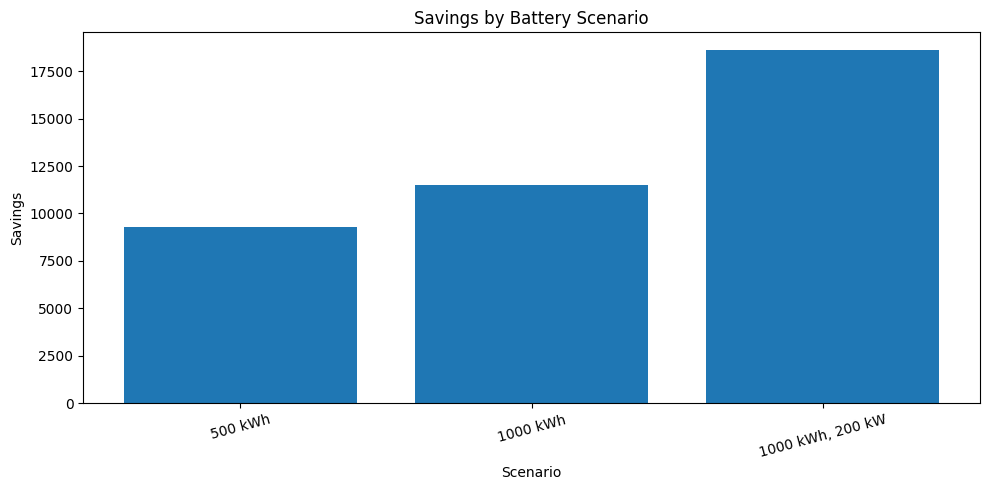

In [ ]:
import matplotlib.pyplot as plt

scenarios = ["500 kWh", "1000 kWh", "1000 kWh, 200 kW"]
savings = [9306.98, 11512.89, 18613.96]

plt.figure(figsize=(10,5))
plt.bar(scenarios, savings)
plt.title("Savings by Battery Scenario")
plt.xlabel("Scenario")
plt.ylabel("Savings")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("scenario_comparison.png", bbox_inches="tight")
plt.show()